In [1]:
import os
import json
import sys
import copy
from glob import glob
from tqdm import tqdm, trange


import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

In [2]:
sys.path.append('..')

In [3]:
from CRT_utils.CRT.core.dataset import COCODataset, COCODatasetWithID, COCODatasetMixOR, COCODatasetFullMix

In [4]:
! cd ../datasets/COCO18_dset_for_CRT_training && ls

annotations                  filtered_val_metadata.json
annotations.json             image_info_test-dev2017.json
category_idx_dict.pkl        image_info_test2017.json
coco18_for_crt               image_info_test2017.zip
coco18_for_crt_test          train_metadata.json
coco18_for_crt_test.zip      train.json
coco18_for_crt.zip           val_metadata.json
coco18_newtest.json          val.json
coco18_newtrain.json         VHhumanStats_noContext.mat
coco18_test.json


In [5]:
with open('../datasets/COCO18_dset_for_CRT_training/coco18_newtrain.json', 'rb') as file:
    train_metadata = json.load(file)

In [6]:
images_in_train_metadata = [image['file_name'] for image in train_metadata['images']]

In [7]:
images_in_train_dataset_dir = list(map(
    lambda x: x.split('/')[-1],
    glob('../datasets/COCO18_dset_for_CRT_training/coco18_for_crt/*')
))

In [8]:
not_exist_train_images = []

for image in images_in_train_metadata:
    if image not in images_in_train_dataset_dir:
        not_exist_train_images.append(image)

In [9]:
len(images_in_train_metadata)

51500

In [10]:
len(images_in_train_dataset_dir)

51607

In [11]:
not_exist_train_images

[]

In [12]:
with open('../datasets/COCO18_dset_for_CRT_training/coco18_newtest.json', 'rb') as file:
    test_metadata = json.load(file)
    

In [13]:
for i in range(len(test_metadata['images'])):
    
    image = test_metadata['images'][i]
    
    image_filename = image['file_name']
    
    if len(image_filename) > 16:
        image_filename = image_filename[-16:]
    
    test_metadata['images'][i]['file_name'] = image_filename
    

In [15]:
from PIL import Image

In [18]:
image_dir = '../datasets/COCO18_dset_for_CRT_training/coco18_for_crt/'

img_h, img_w = 1050, 1680

for i in range(len(test_metadata['images'])):
    
    image = test_metadata['images'][i]
    annotation = test_metadata['annotations'][i]
    
    
    
    image_filename = image['file_name']
    

        
    image_path = os.path.join(image_dir, image_filename)
    
    image = Image.open(image_path)
    image = image.convert("RGB")
    
    xmin, ymin, w, h = annotation["bbox"]
    
    bbox = [
        xmin / img_w * image.width,
        ymin / img_h * image.height,
        w    / img_w * image.width,
        h    / img_h * image.height
    ]
    
    test_metadata['annotations'][i]['bbox'] = bbox
    


In [16]:
test_metadata['images'][:10]

[{'file_name': '000000005649.jpg', 'height': 1050, 'width': 1680, 'id': 0},
 {'file_name': '000000292579.jpg', 'height': 1050, 'width': 1680, 'id': 1},
 {'file_name': '000000306466.jpg', 'height': 1050, 'width': 1680, 'id': 2},
 {'file_name': '000000165955.jpg', 'height': 1050, 'width': 1680, 'id': 3},
 {'file_name': '000000371654.jpg', 'height': 1050, 'width': 1680, 'id': 4},
 {'file_name': '000000067052.jpg', 'height': 1050, 'width': 1680, 'id': 5},
 {'file_name': '000000442443.jpg', 'height': 1050, 'width': 1680, 'id': 6},
 {'file_name': '000000262172.jpg', 'height': 1050, 'width': 1680, 'id': 7},
 {'file_name': '000000524471.jpg', 'height': 1050, 'width': 1680, 'id': 8},
 {'file_name': '000000182096.jpg', 'height': 1050, 'width': 1680, 'id': 9}]

In [20]:
test_metadata['annotations'][0]

{'area': 99999,
 'iscrowd': 0,
 'image_id': 0,
 'bbox': [59.80952380952381,
  152.68571428571428,
  111.23809523809524,
  91.42857142857142],
 'category_id': 62}

In [19]:
with open('../datasets/COCO18_dset_for_CRT_training/coco18_newtest_cleaned.json', 'w') as file:
    json.dump(test_metadata, file)

In [25]:
train_metadata['annotations'][:10]

[{'segmentation': [[578.17,
    274.95,
    576.92,
    271.19,
    578.8,
    263.05,
    579.43,
    259.29,
    577.55,
    256.15,
    575.04,
    251.77,
    571.28,
    249.26,
    568.15,
    244.87,
    568.15,
    239.23,
    573.79,
    233.59,
    577.55,
    232.34,
    584.44,
    232.34,
    591.33,
    229.2,
    595.09,
    229.83,
    595.72,
    229.83,
    602.61,
    229.83,
    605.75,
    234.22,
    605.75,
    240.48,
    605.75,
    246.12,
    601.36,
    251.14,
    600.73,
    251.77,
    600.11,
    257.41,
    599.48,
    266.81,
    597.6,
    271.82,
    596.35,
    272.45,
    588.83,
    272.45,
    579.43,
    273.07]],
  'area': 1169.2116500000013,
  'iscrowd': 0,
  'image_id': 206784,
  'bbox': [568.15, 229.2, 37.6, 45.75],
  'category_id': 64,
  'id': 18912},
 {'segmentation': [[224.63,
    294.65,
    216.55,
    270.39,
    220.01,
    253.06,
    217.7,
    251.33,
    222.32,
    242.66,
    214.24,
    242.09,
    210.77,
    243.82,
    207.3

In [11]:
images_in_test_metadata = [image['file_name'] for image in test_metadata['images']]

In [12]:
len(images_in_test_metadata)

3101

In [13]:
images_in_test_dataset_dir = list(map(
    lambda x: x.split('/')[-1],
    glob('../datasets/COCO18_dset_for_CRT_training/coco18_for_crt_test/*')
))

In [14]:
len(images_in_test_dataset_dir)

2252

In [15]:
not_exist_test_images = []
not_needed_test_images = []

for image in images_in_test_metadata:
    if image not in images_in_test_dataset_dir:
        not_exist_test_images.append(image)
        
for image in images_in_test_dataset_dir:
    if image not in images_in_test_metadata:
        not_needed_test_images.append(image)

In [16]:
len(not_exist_test_images)

2994

In [17]:
len(images_in_test_dataset_dir)

2252

In [18]:
len(not_needed_test_images)

2150

In [34]:
test_images_in_train_images = []

for image in images_in_test_metadata:
    if image in images_in_train_metadata:
        test_images_in_train_images.append(image)

In [35]:
len(test_images_in_train_images)

2477

Pretty sus! since the test images overlap with the train images

Need to do some more test on annotation to see if they use the same annotation


In [21]:
train_metadata['images'][0]

{'license': 4,
 'file_name': '000000522418.jpg',
 'coco_url': 'http://images.cocodataset.org/train2017/000000522418.jpg',
 'height': 480,
 'width': 640,
 'date_captured': '2013-11-14 11:38:44',
 'flickr_url': 'http://farm1.staticflickr.com/1/127244861_ab0c0381e7_z.jpg',
 'id': 522418}

In [84]:
test_metadata['info']

{'description': 'COCO 2017 Dataset',
 'url': 'http://cocodataset.org',
 'version': '1.0',
 'year': 2017,
 'contributor': 'COCO Consortium',
 'date_created': '2017/09/01'}

In [23]:
test_metadata['annotations'][0]

{'area': 99999,
 'iscrowd': 0,
 'image_id': 0,
 'bbox': [157, 334, 292, 200],
 'category_id': 62}

In [24]:
test_metadata['images'][3]

{'file_name': '000000165955.jpg', 'height': 1050, 'width': 1680, 'id': 3}

In [25]:
file_name_2_annotation_idx_train = {}
file_name_2_annotation_id_train = {}

annotation_id_2_image_id_train = {}
annotation_id_2_annotation_idx_train = {}
image_id_to_filename_train = {}

for i in range(len(train_metadata['annotations'])):
    
    annotation = train_metadata['annotations'][i]
    
    annotation_id = annotation['id']
    
    image_id = annotation['image_id']
    
    annotation_id_2_image_id_train[annotation_id] = image_id
    
    annotation_id_2_annotation_idx_train[annotation_id] = i


for i in range(len(train_metadata['images'])):
    
    image = train_metadata['images'][i]
    
    image_id = image['id']
    
    image_filename = image['file_name']
    
    image_id_to_filename_train[image_id] = image_filename
    

for annotation_id, image_id in annotation_id_2_image_id_train.items():
    
    file_name = image_id_to_filename_train[image_id]
    
    annotation_idx = annotation_id_2_annotation_idx_train[annotation_id]
    
    file_name_2_annotation_id_train[file_name] = annotation_id
    file_name_2_annotation_idx_train[file_name] = annotation_idx
    


In [42]:
image_file_name_to_image_idx_test = {}
image_file_name_to_image_id_test = {}
image_id_to_image_file_name_test = {}

for i in range(len(test_metadata['images'])):
    
    image = test_metadata['images'][i]
    
    image_id = image['id']
    
    image_filename = image['file_name']
    
    image_file_name_to_image_id_test[image_filename] = image_id
    
    image_file_name_to_image_idx_test[image_filename] = i
    
    image_id_to_image_file_name_test[image_id] = image_filename

    

In [131]:
class_overlap_count = 0
test_annotation_overlap_idx_2_train_annotation_overlap_idx = {}
test_annotation_not_overlap_idx_2_train_annotation_overlap_idx = {}

for image_filename in set(test_images_in_train_images):
    
    train_annotation_idx = file_name_2_annotation_idx_train[image_filename]
    
    train_annotation_category = train_metadata['annotations'][train_annotation_idx]['category_id']
    
    test_annotation_idx = image_file_name_to_image_idx_test[image_filename]
    
    test_annotation_category = test_metadata['annotations'][test_annotation_idx]['category_id']
    
    if train_annotation_category == test_annotation_category:
        class_overlap_count += 1
        
        test_annotation_overlap_idx_2_train_annotation_overlap_idx[test_annotation_idx] = train_annotation_idx
    else:
        test_annotation_not_overlap_idx_2_train_annotation_overlap_idx[test_annotation_idx] = train_annotation_idx
        
print(class_overlap_count)

981


In [31]:
list(test_annotation_overlap_idx_2_train_annotation_overlap_idx.keys())[:10]

[0, 1, 3, 6, 7, 8, 10, 11, 13, 15]

In [38]:
list(test_annotation_not_overlap_idx_2_train_annotation_overlap_idx.keys())[:10]

[2651, 4, 5, 9, 12, 14, 17, 18, 20, 22]

In [135]:
len(test_annotation_not_overlap_idx_2_train_annotation_overlap_idx)

1447

In [133]:
len(test_annotation_overlap_idx_2_train_annotation_overlap_idx)

981

In [134]:
len(set(test_images_in_train_images))

2428

In [136]:
len(test_metadata['images'])

3101

In [141]:
test_image_distinct = {image['file_name'] for image in test_metadata['images']}
len(test_image_distinct)

3047

In [119]:
test_idx = 1

print(test_metadata['annotations'][test_idx])

print()
print(train_metadata['annotations'][test_annotation_overlap_idx_2_train_annotation_overlap_idx[test_idx]])
print()
print('train image:', image_id_to_filename_train[train_metadata['annotations'][test_annotation_overlap_idx_2_train_annotation_overlap_idx[test_idx]]['image_id']])

{'area': 99999, 'iscrowd': 0, 'image_id': 1, 'bbox': [141, 0, 200, 301], 'category_id': 62}

{'segmentation': [[52.34, 0.0, 62.97, 52.09, 72.48, 99.93, 56.82, 102.44, 41.71, 32.51, 40.59, 30.0, 21.85, 33.07, 38.92, 106.92, 35.56, 108.04, 17.1, 32.79, 0.32, 35.31, 0.0, 21.05, 12.62, 18.81, 11.78, 17.41, 3.39, 8.18, 0.32, 4.54, 0.0, 0.07, 1.99, 0.07, 15.42, 11.82, 18.22, 17.97, 37.8, 16.29, 37.8, 12.65, 35.0, 0.35]], 'area': 2726.3001499999996, 'iscrowd': 0, 'image_id': 292579, 'bbox': [0.0, 0.0, 72.48, 108.04], 'category_id': 62, 'id': 2190342}

train image: 000000292579.jpg


In [43]:
test_idx = 4

print(test_metadata['annotations'][test_idx])

print("test image:", image_id_to_image_file_name_test[test_idx])

print()
print(train_metadata['annotations'][test_annotation_not_overlap_idx_2_train_annotation_overlap_idx[test_idx]])
print('train image:', image_id_to_filename_train[train_metadata['annotations'][test_annotation_not_overlap_idx_2_train_annotation_overlap_idx[test_idx]]['image_id']])

{'area': 99999, 'iscrowd': 0, 'image_id': 4, 'bbox': [213, 525, 131, 134], 'category_id': 62}
test image: 000000371654.jpg

{'segmentation': [[542.4, 233.54, 552.88, 235.66, 564.43, 237.92, 564.43, 239.11, 554.74, 237.78, 544.39, 236.06, 540.81, 235.53, 542.27, 233.94]], 'area': 40.16835000000022, 'iscrowd': 0, 'image_id': 371654, 'bbox': [540.81, 233.54, 23.62, 5.57], 'category_id': 49, 'id': 1891278}
train image: 000000371654.jpg


In [98]:
dataset_train = COCODataset(
    '../datasets/COCO18_dset_for_CRT_training/coco18_newtrain.json', 
    '../datasets/COCO18_dset_for_CRT_training/coco18_for_crt', 
    image_size      = (224,224), 
    # _____ ORIGINAL CODE _____
    normalize_means = [0.5, 0.5, 0.5], 
    normalize_stds  = [0.5, 0.5, 0.5],
    # _____ ORIGINAL CODE _____
    
    # _____ MODIFIED VERSION _____
#     normalize_means = [0.5, 0.5, 0.5], 
#     normalize_stds  = [0.5, 5, 0.5]
    # _____ MODIFIED VERSION _____
    
    # _____ ADDED CODE _____
    category_dic_dir = '../datasets/COCO18_dset_for_CRT_training/category_idx_dict.pkl'
    
    # _____ ADDED CODE _____
    
)

reverse_id2id = {value: key for key, value in dataset_train.id2idx.items()}
id2name = {x['id']: x['name'] for x in dataset_train.coco_dict['categories']}


-------------------------------
Annotation Counts
-------------------------------
potted plant               8631
tv                         5803
bottle                    24070
chair                     38073
car                       43533
stop sign                  1983
clock                      6320
cup                       20574
fork                       5474
knife                      7760
bowl                      14323
toilet                     4149
laptop                     4960
mouse                      2261
keyboard                   2854
microwave                  1672
oven                       3334
sink                       5609
Total                    201383
-------------------------------



Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


knife
target_area/context_area = tensor(0.0005)
tensor([0.8450, 0.5482, 0.0369, 0.0131])


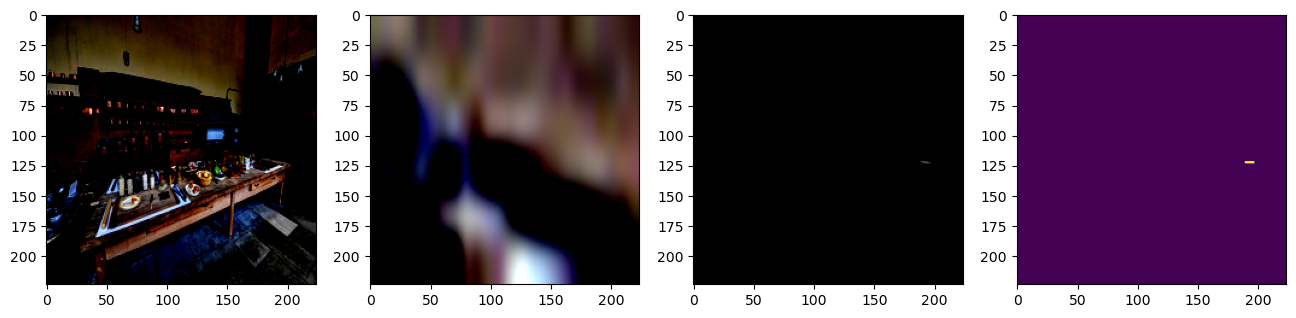

In [125]:
test_idx = 4

if test_idx in test_annotation_overlap_idx_2_train_annotation_overlap_idx:
    train_annotation_id = train_metadata['annotations'][test_annotation_overlap_idx_2_train_annotation_overlap_idx[test_idx]]['id']
else:
    train_annotation_id = train_metadata['annotations'][test_annotation_not_overlap_idx_2_train_annotation_overlap_idx[test_idx]]['id']
    
    
idx = annotation_id_2_annotation_idx_train[train_annotation_id]

context, target, bbox, category = dataset_train[idx]

solution = torch.zeros(context.shape[1], context.shape[2])

im_h, im_w = context.shape[1], context.shape[2]
x_min, y_min, w, h = bbox

norm_bbox = int(x_min * im_w), int(y_min * im_h), int(w * im_w), int(h * im_h)

solution[
    norm_bbox[1]:norm_bbox[1]+norm_bbox[3],
    norm_bbox[0]:norm_bbox[0]+norm_bbox[2]
] = 1

fig, ax = plt.subplots(1, 4, figsize=(16, 16))

print(id2name[reverse_id2id[category]])
print('target_area/context_area =', bbox[2]*bbox[3])
print(bbox)

ax[0].imshow(context.permute(1,2,0))
ax[1].imshow(target.permute(1,2,0))
ax[2].imshow((context*solution).permute(1,2,0))
ax[3].imshow(solution)


In [126]:
dataset_test = COCODataset(
    '../datasets/COCO18_dset_for_CRT_training/coco18_newtest.json', 
    '../datasets/COCO18_dset_for_CRT_training/coco18_for_crt', 
    image_size      = (224,224), 
    # _____ ORIGINAL CODE _____
    normalize_means = [0.5, 0.5, 0.5], 
    normalize_stds  = [0.5, 0.5, 0.5],
    # _____ ORIGINAL CODE _____
    
    # _____ MODIFIED VERSION _____
#     normalize_means = [0.5, 0.5, 0.5], 
#     normalize_stds  = [0.5, 5, 0.5]
    # _____ MODIFIED VERSION _____
    
    # _____ ADDED CODE _____
    category_dic_dir = '../datasets/COCO18_dset_for_CRT_training/category_idx_dict.pkl'
    
    # _____ ADDED CODE _____
    
)

reverse_id2id = {value: key for key, value in dataset_test.id2idx.items()}
id2name = {x['id']: x['name'] for x in dataset_test.coco_dict['categories']}


-------------------------------
Annotation Counts
-------------------------------
chair                       253
fork                        230
sink                        279
tv                          281
bowl                        141
car                         104
clock                       119
cup                         276
keyboard                    184
knife                       141
laptop                      123
mouse                       109
oven                        101
potted plant                154
toilet                      158
bottle                      166
stop sign                   126
microwave                   156
Total                      3101
-------------------------------



Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


chair
target_area/context_area = tensor(0.0100)
tensor([0.1268, 0.5000, 0.0780, 0.1276])


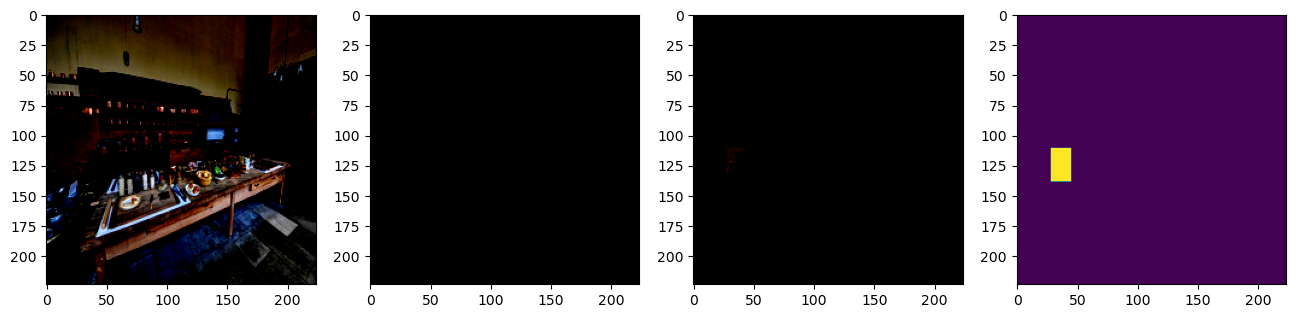

In [127]:
idx = test_idx

context, target, bbox, category = dataset_test[idx]

solution = torch.zeros(context.shape[1], context.shape[2])

im_h, im_w = context.shape[1], context.shape[2]

annotation = dataset_test.annotations[idx]

file_name = dataset_test.id2file[annotation["image_id"]].split('/')[-1]

ori_img_h = 0
ori_img_w = 0


for image in train_metadata['images']:
    if image['file_name'] == file_name:
        ori_img_h = image['height']
        ori_img_w = image['width']
        
        break

ratio_h = ori_img_h / 1050
ratio_w = ori_img_w / 1680

bbox[0] = bbox[0] * ratio_w
bbox[1] = bbox[1] * ratio_h
bbox[2] = bbox[2] * ratio_w
bbox[3] = bbox[3] * ratio_h








# im_h, im_w = 1050, 1680
x_min, y_min, w, h = bbox

norm_bbox = int(x_min * im_w), int(y_min * im_h), int(w * im_w), int(h * im_h)

solution[
    norm_bbox[1]:norm_bbox[1]+norm_bbox[3],
    norm_bbox[0]:norm_bbox[0]+norm_bbox[2]
] = 1

fig, ax = plt.subplots(1, 4, figsize=(16, 16))

print(id2name[reverse_id2id[category]])
print('target_area/context_area =', bbox[2]*bbox[3])
print(bbox)

ax[0].imshow(context.permute(1,2,0))
ax[1].imshow(target.permute(1,2,0))
ax[2].imshow((context*solution).permute(1,2,0))
ax[3].imshow(solution)

In [102]:
bbox

tensor([2.1891, 0.0750, 0.2094, 0.6562])

In [89]:
with open('../datasets/COCO18_dset_for_CRT_training/image_info_test2017.json', 'rb') as file:
    original_test = json.load(file)

In [90]:
original_test['images'][0]

{'license': 6,
 'file_name': '000000466319.jpg',
 'coco_url': 'http://images.cocodataset.org/test2017/000000466319.jpg',
 'height': 480,
 'width': 640,
 'date_captured': '2013-11-14 11:04:33',
 'id': 466319}

In [91]:
all_images_files = [image['file_name'] for image in original_test['images']]

In [92]:
'000000165955.jpg' in all_images_files

False

In [105]:
for image in train_metadata['images']:
    if image['file_name'] == '000000442443.jpg':
        print(image)
        break

{'license': 3, 'file_name': '000000442443.jpg', 'coco_url': 'http://images.cocodataset.org/train2017/000000442443.jpg', 'height': 480, 'width': 640, 'date_captured': '2013-11-23 05:56:54', 'flickr_url': 'http://farm4.staticflickr.com/3155/2306835715_65de1af4d6_z.jpg', 'id': 442443}


In [106]:
for image in test_metadata['images']:
    if image['file_name'] == '000000442443.jpg':
        print(image)
        break

{'file_name': '000000442443.jpg', 'height': 1050, 'width': 1680, 'id': 6}


In [107]:
test_metadata['images']

[{'file_name': '000000005649.jpg', 'height': 1050, 'width': 1680, 'id': 0},
 {'file_name': '000000292579.jpg', 'height': 1050, 'width': 1680, 'id': 1},
 {'file_name': '000000306466.jpg', 'height': 1050, 'width': 1680, 'id': 2},
 {'file_name': '000000165955.jpg', 'height': 1050, 'width': 1680, 'id': 3},
 {'file_name': '000000371654.jpg', 'height': 1050, 'width': 1680, 'id': 4},
 {'file_name': '000000067052.jpg', 'height': 1050, 'width': 1680, 'id': 5},
 {'file_name': '000000442443.jpg', 'height': 1050, 'width': 1680, 'id': 6},
 {'file_name': '000000262172.jpg', 'height': 1050, 'width': 1680, 'id': 7},
 {'file_name': '000000524471.jpg', 'height': 1050, 'width': 1680, 'id': 8},
 {'file_name': '000000182096.jpg', 'height': 1050, 'width': 1680, 'id': 9},
 {'file_name': '000000297441.jpg', 'height': 1050, 'width': 1680, 'id': 10},
 {'file_name': '000000578793.jpg', 'height': 1050, 'width': 1680, 'id': 11},
 {'file_name': '000000277630.jpg', 'height': 1050, 'width': 1680, 'id': 12},
 {'file_n

In [22]:
train_metadata['images'][:2]

[{'license': 4,
  'file_name': '000000522418.jpg',
  'coco_url': 'http://images.cocodataset.org/train2017/000000522418.jpg',
  'height': 480,
  'width': 640,
  'date_captured': '2013-11-14 11:38:44',
  'flickr_url': 'http://farm1.staticflickr.com/1/127244861_ab0c0381e7_z.jpg',
  'id': 522418},
 {'license': 3,
  'file_name': '000000318219.jpg',
  'coco_url': 'http://images.cocodataset.org/train2017/000000318219.jpg',
  'height': 640,
  'width': 556,
  'date_captured': '2013-11-14 13:02:53',
  'flickr_url': 'http://farm5.staticflickr.com/4125/5094763076_813ea2751b_z.jpg',
  'id': 318219}]

In [123]:
len(dataset_test)

3101

In [124]:
for i in range(len(dataset_test)):
    dataset_test[i]

FileNotFoundError: [Errno 2] No such file or directory: '/Users/nguyentuan/Mirror/STUDY_DOCUMENTS/FYP/TCT code/TCT-visual-search/datasets/COCO18_dset_for_CRT_training/coco18_for_crt/000000482978.jpg'

In [154]:
import requests

test_dir = '../datasets/COCO18_dset_for_CRT_training/coco18_for_crt/'
original_url = 'http://images.cocodataset.org/'

for i in tqdm(range(len(test_metadata['images']))):
    
    file_name = test_metadata['images'][i]['file_name']
    
    file_name = file_name[-16:]
    
    file_path = os.path.join(test_dir, file_name)
    
    if os.path.exists(file_path):
        continue
    
    
    
    url = os.path.join(original_url, 'train2017', file_name)
    
    res = requests.get(url, stream=True)
    
    if res.status_code == 404:
        url = os.path.join(original_url, 'val2017', file_name)
        res = requests.get(url, stream=True)
    else:
        url = os.path.join(original_url, 'test2017', file_name)
        res = requests.get(url, stream=True)
        
    res.raise_for_status()
    
    with open(file_path, 'wb') as file:
        file.write(res.content)



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3101/3101 [03:10<00:00, 16.27it/s]


In [145]:
url = 'http://images.cocodataset.org/val2017/00000048fsdf.jpg'
res = requests.get(url)